## BMEB W4020: Circuits in the Brain 2025 Fall Homework #2

Author: [Shashwat Shukla](shashwat.shukla@columbia.edu), [Bruce Yi Bu](yb2520@columbia.edu)

Based on Previous Work by: Tingkai Liu, Mehmet Kerem Turkcan, Chung-Heng Yeh, Konstantinos Psychas, Teng Yang, Cong Han

Copyright 2025 Shashwat Shukla, Tingkai Liu, Bruce Yi Bu, and Aurel A. Lazar

### Names and UNIs
 # Alexander Speer (aes2376) and Andre Perez (avp2141)

## Problem 1: PRC of Rinzel Model
In this problem, you are asked to do the following:

1. Implement Winfree's method for approximating the Phase Response Curve (PRC) for Voltage of the Rinzel Model, which is called the `HodgkinHuxleyRinzel` model in the `compneuro` package. Use simple words to describe the procedures and your method (via #comments).
2. Generate spike train with Rinzel neuron and the I/O equivalent project-integrate-and-fire (PIF) neuron when the input is [$I_{ext}(t)$](#note-on-I-ext). Use simple words to describe your implementation of PIF (via #comments).
3. Evaluate the mean $\mu$ and standard deviation $\sigma$ of the difference between the corresponding spike times of the Rinzel neuron and the equivalent PIF neuron for bandlimited stimulus described by [equation](#input) scaled to have maximum amplitude $c > 0$ (i.e. $\max_{t}|u(t)| = c$). Plot these statistics as a function of $c$ across values of $c$.
    - **Note 1**: You should generate new inputs $u(t)$ (with different random coefficients) to ensure that the error statistics are not biased by the form of the input stimulus.
    - **Note 2**: The value of $c$ should not be so large that the limit cycle of the Rinzel model collapses to singularity. It would be instructive to look at F-I curve of the Rinzel model first to find a range of input current values that gives periodic spiking (this was explored in the last homework).

#### Note on $I_{ext} = I + u(t)$ <a name="note-on-I-ext"></a>
Starting this homework, the injected current $I_{ext}$ will have the form $I+u(t)$, where $I$ refers to _injected current_ and $u(t)$ is the _stimulus_. In particular:


1. $I$: injected (bias) current is a _constant_ value for all time that is injected to the neuron model. You can consider this value as the _average_/DC value of the input $I_{ext}$. Since this value is not time-varying, it contains _no information_ (in the sense of entropy). For this reason, we don't refer to $I$ as _stimulus_. However, the bias $I$ will change the shape of the limit cycle $\Gamma$ (or the periodic solution ${\bf x}^0$) of the neuron model, where the higher the bias current $I$, the smaller the limit cycle and the faster the neuron oscillates. For this reason, we can consider the dynamic of the neuron model to be _parametrized_ / _indexed_ by the bias $I$.

2. $u(t)$: this is a time-varying signal that has information content. If we consider $I$ as the DC value of $I_{ext}$, then $u(t)$ will be a zero-mean signal that corresponds to local perturbation of the neuron dynamic around the limit cycle $\Gamma$. This is the input signal that we seeks to decode from the neuron spike times.

### Input Stimulus $u(t)$ - Complex Exponential <a name="input"></a>
The input stimulus here is a zero-DC valued complex exponential of order $M=5$ on support $t\in[0, 200]$ ms with bandwidth $\Omega = 2\pi \cdot 20 \quad [rad\cdot s^-1]$,
$$
u(t)= \sum^{M}_{m=-M}a_{m} \exp\left(j\frac{m\Omega t}{M}\right)
$$

Note that for stimulus $u(t)$ to be real-valued signal, the coefficients $a_m$ need to be conjugate-symmetric. In another word, $a_m = \overline{a_{-m}} = Re(a_{-m}) - j Im(a_{-m})$,
where $Re(\cdot), Im(\cdot)$ are the _real_ and _imaginary_ parts of the complex number respectively. The stimulus $u(t)$ should be zero-DC valued, which means that $a_0 = 0$. This input stimulus $u(t)$ is additively coupled to a periodically spiking Rinzel neuron.

## Problem 2: Synaptic Input and PRC

In the previous problem we explored how perturbations (in particular, the stimulus $u(t)$) can change the spike times of a periodically firing neuron.
In this problem we explore how presynaptic voltage spikes are chemically transduced by synapses into transient neurotransmitter concentrations, and how this impacts postsynaptic spike times and relates to PRC.

For this problem, we treat the synaptic current $I_{syn}$ as a perturbation to the total current $I_{ext} = I + I_{syn}$, where $I$ is the injected current.

1. Simulate a postsynaptic `HodgkinHuxley` neuron with $I=20$ pA (while omitting $I_{syn}$), plot the periodic spike train ($V_{post}$) along with the corresponding stable limit cycle. Note the timing of the spikes.
2. We assume that the neurotransmitter release $[NT]$ at a synapse, due to the presynaptic neuron firing at time $t_k$, can be approximated as a dirac delta spike
$$[NT](t) = [NT]_{max} \cdot \delta(t-t_k)\\
\text{where $t_k$ = presynaptic spike time}\\
\text{where $[NT]_{max}$ = 250}
$$
Referencing the PRC you obtained from Problem 1, generate and plot neurotransmitter concentration $[NT]$ for (clearly label your plots):  
    1.  $t_k = \mathrm{argmax}(PRC)$ (time corresponding to the maximal phase response)  
    2.  $t_k = \mathrm{argmin}(PRC)$ (time corresponding to the minimal phase response)  

3. Considering the synaptic current as $u(t)$ to the postsynaptic neuron, simulate an AMPA synapse with the above $[NT]$ inputs, along with the postsynaptic neuron voltage $V_{post}$. Recall that $I_{syn}(t)= g_{syn}(t) \cdot (V_{post}(t)-E_{rev})$.  
Plot the following as functions of time:
    1. Synaptic Conductance  
    2. Synaptic Current   
    3. Postsynaptic Neuron Voltage  
4. Overlay the resulting postsynaptic neuron voltage $V_{post}$ and limit cycle on the plots from Problem *2.1* to show the phase shift due to the injection of synpatic current. Clearly label the traces with an appropriate legend.
5. Repeat steps 3 and 4 with a GABA_A synapse.
6. Comment on how the different synapses and the timing of presynaptic input affect the behaviour of the postsynaptic neuron.

**For your own exploration (not graded)**:
Repeat steps 2 to 4 (only AMPA) with the following $[NT]=[NT]_{max} \cdot \mathbf{1}_{t_k}$ where $t_k = [\space \mathrm{argmax}(PRC),\space \mathrm{argmin}(PRC) \space]$.
Is is the behaviour of the postsynaptic neuron as expected (in terms of phase)? Explain your observations and comment on how you would expect the postsynaptic voltage to evolve with an increasing number of presynaptic spikes?


**Note**: By convention, synaptic current $I_{syn}$ has negative value because it denotes _inward_ current to the neuron. Therefore, to use simulation kernels (including `hodgkin_huxley`), the input current $I_{ext}$ will be $I_{ext} = -I_{syn}$.

**Note**: Use the AMPA, GABA_A synapse models as defined in the `compneuro` package.  



# Before you start...
### The code skeleton
* we provide a skeleton of the code for HW2, you will find helper functions as well as headers of functions that need to be completed (look for "**TO DO**" comments and markdowns)
* note that you are not required to follow this sequence; the skeleton is just provided for convenience but we highly recommend using it, and you are feel to modify or add custom functions

### Miscellaneous (attention)
* please remember to include your name in the corresponding field at the start of this notebook, otherwize an automatic 0 grade will be received for any missing member
* please clearly present your solutions and answers with proper use of plots, markdown and comments
* please start the assignment as soon as possible, submission deadlines are strictly followed and late submissions after we posted the solution (ususlaly on the same day as the deadline) will receive automatic 0
* please email both TAs at least 48hrs ahead of deadline if you cannot submit an assignment on time (due to exam schedules or  overwhelming deadlines, etc), we are flexible as long as we are informed
* please post your questions on Ed Discussions, and attend the office hours (every Thursday evening); **more on Ed**:
    * while discussing on Ed, please make good use of the reply and comment features inside threads to avoid cluttering with multiple threads regarding the same question from the same user
    * please refrain from asking questions or posting threads that would explicitly share the right answer with everyone
    * only post code snipets when you have narrowed down the issue to that particular section and only share ploted results only when you have good reason to suspect their correctness
    * once you finish debugging your code by the end of a thread, please avoid languages such as "is this correct now?" since we aren't really allowed to explicitly say yes when they are; be confident in your hardwork.

## Setup

python -m jupyter nbconvert --to html "C:\Users\Alexander Speer\Downloads\BMEB_4020_HW2_Handout_2025 (2).ipynb"

python3 -m jupyter nbconvert --to html copy_of_alex_andre_edit.ipynb

In [1]:

from google.colab import drive
drive.mount('/content/drive')

#make sure you're not loading a different comp neuro package or one in your drive
import sys
# remove any stale copy
if 'compneuro' in sys.modules:
    del sys.modules['compneuro']
sys.path.insert(0, "/content/drive/MyDrive/CCircuits/hw2")


%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

from compneuro.neurons.hodgkin_huxley import HodgkinHuxley
from compneuro.neurons.hodgkin_huxley_rinzel import HodgkinHuxleyRinzel
from compneuro.utils.signal import spike_detect

np.random.seed(0)
plt.rcParams.update({"figure.figsize": (10, 5), "figure.dpi": 80})

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Problem 1 - PRC of Rinzel model

## Initialization

In [2]:
# TODO: Implement signal generator that takes in [time, coefficients, order, Bandwidth] as input
def bandlmt_sig(t, a, M, omega):
    #T vector, basically just generate a bandlimited signal using exponentials
    #coeff w length 2*M + 1
    u = np.zeros_like(t, dtype=complex)
    for m in range(-M, M+1):
        # a is indexed from 0 to 2M, where index M corresponds to m=0
        idx = m + M
        u += a[idx] * np.exp(1j * m * omega * t / M)

    # return the real part.
    return np.real(u)

In [3]:
# TODO: Specify the time resolution for computing PRC.
# The smaller the value the better the Winfree method performs

# NOTE: start with a smaller value to ensure the code works before making it larger
dt = 0.01  # 0.01 ms

In [4]:
# TODO: Specify the bias of Rinzel Model (I in I_ext = I + u(t)).
# This value will be used in both the neuron model itself and its PIF.

bias = 10.0  # pico amp (pA)
# unit is in pico amp

# we suggest refering the injection current amplitude (aka without stimulus)
# that you've experimented with in HW1 that gives robust firing

## Item (i): Extract the PRC

In [5]:
# TODO: Implement Winfree's Method
# As a suggestion, the function should return
# 1. period: the period of oscillation, maybe in number of time-steps
# 2. limitCycle: the output of the state variables [V, R] on a limit cycle
# 3. PRC: the phase response curve of the Voltage along the limit cycle

def winfree(model, I, dt, epsilon=5.0, pulse_duration=0.5):
    """
    Ok lets compute the PRC using Winfree's method.

    Winfree's method: basically just apply small perturbations at some of teh different phases along the limit cycle
    and then measure how much the timing of the next spike ends up being shifted.

    Args:
        model: Neuron model (HodgkinHuxleyRinzel)
        I: Bias current
        dt: Time resolution (in ms)
        epsilon: Perturbation amplitude (in pA)
        pulse_duration: the duration of PRC (in ms)

    Returns:
        period
        limitCycle --> the state variables [V, R]
        PRC voltage
    """


    t_sim = np.arange(0, 0.5, dt * 1e-3)
    I_ext = np.ones_like(t_sim) * I

    res = model.solve(t_sim, I_ext=I_ext, solver='Euler', reset_initial_state=True, verbose=False)
    V_sim = res['V'][0]
    R_sim = res['R'][0]

    # in ms
    t_sim_ms = t_sim * 1e3 #back to ms

    #sanity check V
    print(f"Voltage range: [{np.min(V_sim):.2f}, {np.max(V_sim):.2f}] mV")

    spike_mask = spike_detect(V_sim, height=0, distance=10)  #no double counting
    spike_indices = np.where(spike_mask)[0]

    print(f"Detected {len(spike_indices)} spikes in {t_sim_ms[-1]:.1f} ms")

    if len(spike_indices) < 3:
        plt.figure(figsize=(12, 4))
        plt.plot(t_sim_ms, V_sim)
        plt.xlabel('Time (ms)')
        plt.ylabel('Voltage (mV)')
        plt.title(f'Voltage trace with I={I} pA (only {len(spike_indices)} spike(s) detected)')
        plt.grid(True, alpha=0.3)
        if len(spike_indices) > 0:
            plt.scatter(t_sim_ms[spike_indices], V_sim[spike_indices], c='red', s=50, zorder=5)
        plt.show()
        raise ValueError(f"Not enough spikes detected ({len(spike_indices)}). The neuron may not be firing periodically. Try adjusting bias current.")

    #\last 2 spikes determine period
    period = spike_indices[-1] - spike_indices[-2]

    print(f"Period: {period} time steps = {period * dt:.3f} ms")


    start_idx = spike_indices[-2]
    end_idx = spike_indices[-1]

    limitCycle = {
        'V': V_sim[start_idx:end_idx],
        'R': R_sim[start_idx:end_idx],
        't': (t_sim_ms[start_idx:end_idx] - t_sim_ms[start_idx])
    }

    #Winfree's method
    # for each of teh phase point, apply the perturbation and then lets measure phase shift
    PRC = np.zeros(period)

    print("Computing PRC using Winfree's method...")
    print(f"Perturbation: {epsilon} pA for {pulse_duration} ms")

    # Calculate how many time steps the pulse should last
    pulse_steps = int(pulse_duration / dt)

    for i in tqdm(range(period), desc="Computing PRC"):
        # Set the initial condition to phase i on the limit cycle
        model.states['V'] = np.array([limitCycle['V'][i]])
        model.states['R'] = np.array([limitCycle['R'][i]])

        #simulate for 2 periods w/o preb
        t_ref = np.arange(0, 2 * period * dt * 1e-3, dt * 1e-3)  # seconds
        I_ref = np.ones_like(t_ref) * I
        res_ref = model.solve(t_ref, I_ext=I_ref, solver='Euler',
                             reset_initial_state=False, verbose=False)
        V_ref = res_ref['V'][0]

        # Find next spike in reference trajectory
        spike_mask_ref = spike_detect(V_ref, height=0)
        spike_indices_ref = np.where(spike_mask_ref)[0]

        if len(spike_indices_ref) == 0:
            PRC[i] = 0
            continue

        t_spike_ref = spike_indices_ref[0] * dt  # in ms

        model.states['V'] = np.array([limitCycle['V'][i]])
        model.states['R'] = np.array([limitCycle['R'][i]])

        t_pert = np.arange(0, 2 * period * dt * 1e-3, dt * 1e-3)
        I_pert = np.ones_like(t_pert) * I
        I_pert[0:min(pulse_steps, len(I_pert))] += epsilon

        res_pert = model.solve(t_pert, I_ext=I_pert, solver='Euler',
                              reset_initial_state=False, verbose=False)
        V_pert = res_pert['V'][0]

        spike_mask_pert = spike_detect(V_pert, height=0)
        spike_indices_pert = np.where(spike_mask_pert)[0]

        if len(spike_indices_pert) == 0:
            PRC[i] = 0
            continue

        t_spike_pert = spike_indices_pert[0] * dt  # in ms


        delta_t = t_spike_pert - t_spike_ref
        PRC[i] = delta_t / (epsilon * pulse_duration)

    return period, limitCycle, PRC


In [6]:
# TODO: Simulate your model
rinzel = HodgkinHuxleyRinzel()
period, limitCycle, PRC = winfree(rinzel, bias, dt)

print(f"Period of oscillation: {period * dt:.3f} ms ({period} time steps)")
print(f"Frequency: {1000 / (period * dt):.2f} Hz")

Voltage range: [-74.00, 49.85] mV
Detected 93 spikes in 500.0 ms
Period: 537 time steps = 5.370 ms
Computing PRC using Winfree's method...
Perturbation: 5.0 pA for 0.5 ms


Computing PRC:   0%|          | 0/537 [00:00<?, ?it/s]

Period of oscillation: 5.370 ms (537 time steps)
Frequency: 186.22 Hz


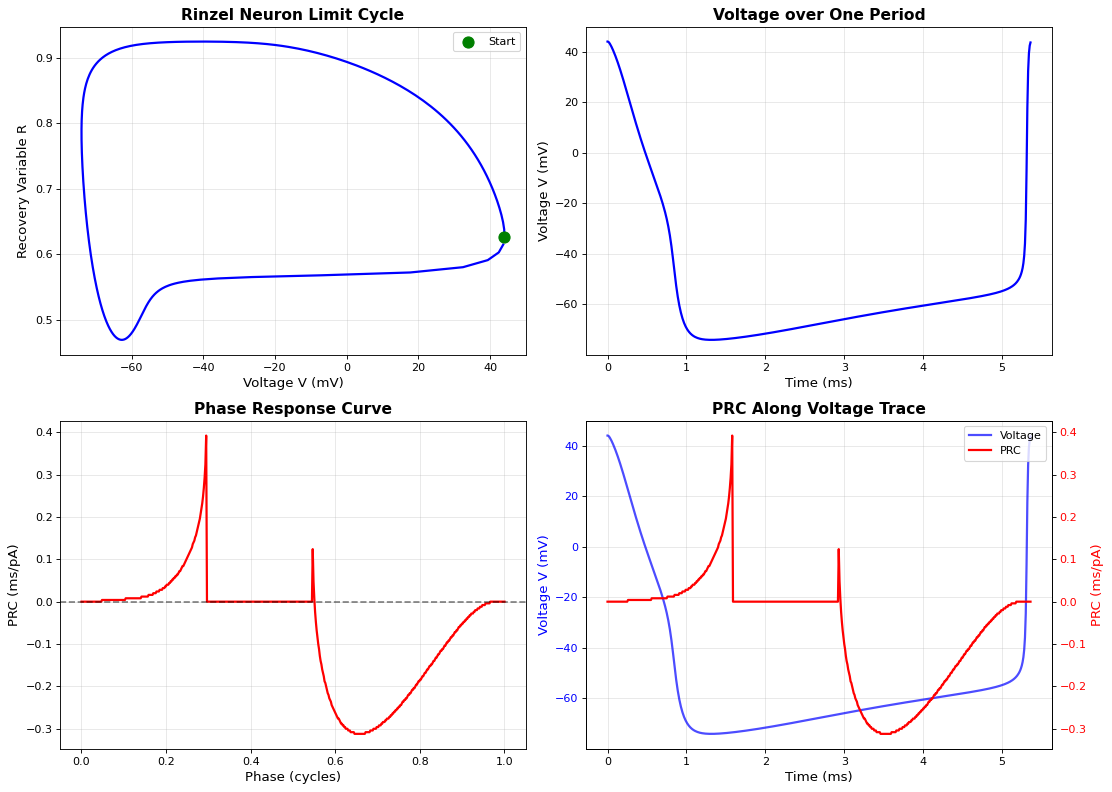


PRC Statistics:
  Max PRC: 0.3920 ms/pA at phase 0.294
  Min PRC: -0.3120 ms/pA at phase 0.644
  Mean PRC: -0.0624 ms/pA
  Std PRC: 0.1292 ms/pA
  Time at max PRC: 1.580 ms
  Time at min PRC: 3.460 ms


In [7]:
# TODO: Visualize the limit cycle and the PRC along it

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# T vector
t_cycle = limitCycle['t']

#V vs R
ax1 = axes[0, 0]
ax1.plot(limitCycle['V'], limitCycle['R'], 'b-', linewidth=2)
ax1.scatter(limitCycle['V'][0], limitCycle['R'][0], c='green', s=100,
           marker='o', label='Start', zorder=5)
ax1.set_xlabel('Voltage V (mV)', fontsize=12)
ax1.set_ylabel('Recovery Variable R', fontsize=12)
ax1.set_title('Rinzel Neuron Limit Cycle', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.legend()

# voltage over one period
ax2 = axes[0, 1]
ax2.plot(t_cycle, limitCycle['V'], 'b-', linewidth=2)
ax2.set_xlabel('Time (ms)', fontsize=12)
ax2.set_ylabel('Voltage V (mV)', fontsize=12)
ax2.set_title('Voltage over One Period', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3)

# prc
ax3 = axes[1, 0]
phase = np.linspace(0, 1, len(PRC))  # normalized
ax3.plot(phase, PRC, 'r-', linewidth=2)
ax3.axhline(y=0, color='k', linestyle='--', alpha=0.5)
ax3.set_xlabel('Phase (cycles)', fontsize=12)
ax3.set_ylabel('PRC (ms/pA)', fontsize=12)
ax3.set_title('Phase Response Curve', fontsize=14, fontweight='bold')
ax3.grid(True, alpha=0.3)

# Prc and voltage trace
ax4 = axes[1, 1]
ax4_twin = ax4.twinx()
ax4.plot(t_cycle, limitCycle['V'], 'b-', linewidth=2, label='Voltage', alpha=0.7)
ax4_twin.plot(t_cycle, PRC, 'r-', linewidth=2, label='PRC')
ax4.set_xlabel('Time (ms)', fontsize=12)
ax4.set_ylabel('Voltage V (mV)', fontsize=12, color='b')
ax4_twin.set_ylabel('PRC (ms/pA)', fontsize=12, color='r')
ax4.set_title('PRC Along Voltage Trace', fontsize=14, fontweight='bold')
ax4.tick_params(axis='y', labelcolor='b')
ax4_twin.tick_params(axis='y', labelcolor='r')
ax4.grid(True, alpha=0.3)


lines1, labels1 = ax4.get_legend_handles_labels()
lines2, labels2 = ax4_twin.get_legend_handles_labels()
ax4.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

plt.tight_layout()
plt.show()

#stats
print(f"\nPRC Statistics:")
print(f"  Max PRC: {np.max(PRC):.4f} ms/pA at phase {np.argmax(PRC)/len(PRC):.3f}")
print(f"  Min PRC: {np.min(PRC):.4f} ms/pA at phase {np.argmin(PRC)/len(PRC):.3f}")
print(f"  Mean PRC: {np.mean(PRC):.4f} ms/pA")
print(f"  Std PRC: {np.std(PRC):.4f} ms/pA")
print(f"  Time at max PRC: {t_cycle[np.argmax(PRC)]:.3f} ms")
print(f"  Time at min PRC: {t_cycle[np.argmin(PRC)]:.3f} ms")

## Item (ii): Compare Spikes of PIF and Rinzel

We first generate a bandlimited signal with random coefficients

In [8]:
# temporal support of the signal [0, 200] ms
t = np.arange(0, 200, dt) # you can use [0,0.2]s  as well if it suits you

# bandwidth: 20Hz
Omega = 2 * np.pi * 20

# order: 5
M = 5

# Amplitude of the signal, you can use other values.
Sig_Amp = 1

am = np.zeros(2*M + 1, dtype=complex)

#a_0 must be 0 for zero-DC signal
# For m = 1 to M, we are just going to be generating random coefficients
for m in range(1, M+1):
    real_part = np.random.randn()
    imag_part = np.random.randn()

    # Set a_m
    am[M + m] = real_part + 1j * imag_part
    # Set a_-m
    am[M - m] = np.conj(am[M + m])

# make sure mean 0
u1 = bandlmt_sig(t, am, M, Omega)
u1 = Sig_Amp * u1 / np.max(np.abs(u1))  #scale to the have max amplitude = Sig_Amp

print(f"Signal u1: mean = {np.mean(u1):.6f}, max = {np.max(u1):.3f}, min = {np.min(u1):.3f}")

Signal u1: mean = 0.000000, max = 1.000, min = -0.762


Simulate the rinzel neuron with bias and bandlimited input added.

In [9]:
# TODO: simulate model and find spikes

#bias current + bandlimited stimulus
I_ext_rinzel = bias + u1

t_sec = t * 1e-3  #ms to seconds

# new Rinzel instance
rinzel_sim = HodgkinHuxleyRinzel()
res_rinzel = rinzel_sim.solve(t_sec, I_ext=I_ext_rinzel, solver='Euler',
                              reset_initial_state=True, verbose=False)

V_rinzel = res_rinzel['V'][0]

print(f"Rinzel simulation complete")
print(f"Voltage range: [{np.min(V_rinzel):.2f}, {np.max(V_rinzel):.2f}] mV")


Rinzel simulation complete
Voltage range: [-74.02, 49.86] mV


In [10]:
# TODO: find spike time indices of Rinzel

# Detect spikes in the  Rinzel output
spike_mask_rinzel = spike_detect(V_rinzel, height=0)
tk_idx_rinzel = np.where(spike_mask_rinzel)[0]

#convert indices to spike times using  ms
tk_rinzel = t[tk_idx_rinzel]

print(f"Rinzel: Detected {len(tk_rinzel)} spikes")
print(f"First few spike times (ms): {tk_rinzel[:5]}")

Rinzel: Detected 38 spikes
First few spike times (ms): [ 0.57  6.2  11.57 16.94 22.31]


### Output of PIF
The t-transform of the PIF neuron can be written as,
$$
\int_{t_k}^{t_{k+1}}(1+\psi(s+\tau(s))u(s))ds = \delta_{t_{k+1}}-\delta_{t_{k}} \approx T, \\
\tau(t) = \psi(t+\tau(t))u(t),~\tau(0)=0.
$$    
We assume that $\tau(s)=0$ , and hence the $t$-transform is reduced to
$$
\int_{t_k}^{t_{k+1}}(1+\psi(s)u(s))ds = T.
$$  

In [11]:
# TODO: Implement the PIF model using the input defined above and the PRC curve computed

def pif(t, u, psi, T, dt):
    """
    PIF neuron model.

    The t-transform of PIF (if were assuming that tau=0):
    ∫_{t_k}^{t_{k+1}} (1 + ψ(s)u(s)) ds = T

    Args:
        t: time vector (in ms)
        u: input stimulus signal (same length as t)
        psi: Phase Response Curve (PRC) over one period
        T: period of oscillation (in ms)
        dt: time resolution (in ms)

    Returns:
        spike_times: array of spike times (in ms)
    """

    spike_times = []
    integral = 0.0
    t_last_spike = 0

    for i in range(len(t)):
        # relative to last spike
        t_since_spike = t[i] - t_last_spike

        #orresponding phase in the PRC
        #wraps around period
        phase_idx = int((t_since_spike % T) / dt) % len(psi)

        #p;RC value at current phase
        psi_val = psi[phase_idx]

        # Integrate perturbed rate
        integral += (1.0 + psi_val * u[i]) * dt

        #have we reached the threshold?
        if integral >= T:
            spike_times.append(t[i])
            integral = 0.0
            t_last_spike = t[i]

    return np.array(spike_times)

print("PIF function defined")


PIF function defined


In [12]:
# TODO: execute the pif and find spike times

T_period = period * dt  # Period in ms
tk_pif = pif(t, u1, PRC, T_period, dt)

print(f"PIF: Generated {len(tk_pif)} spikes")
print(f"First few spike times (ms): {tk_pif[:5]}")

PIF: Generated 37 spikes
First few spike times (ms): [ 5.36 10.74 16.12 21.5  26.87]


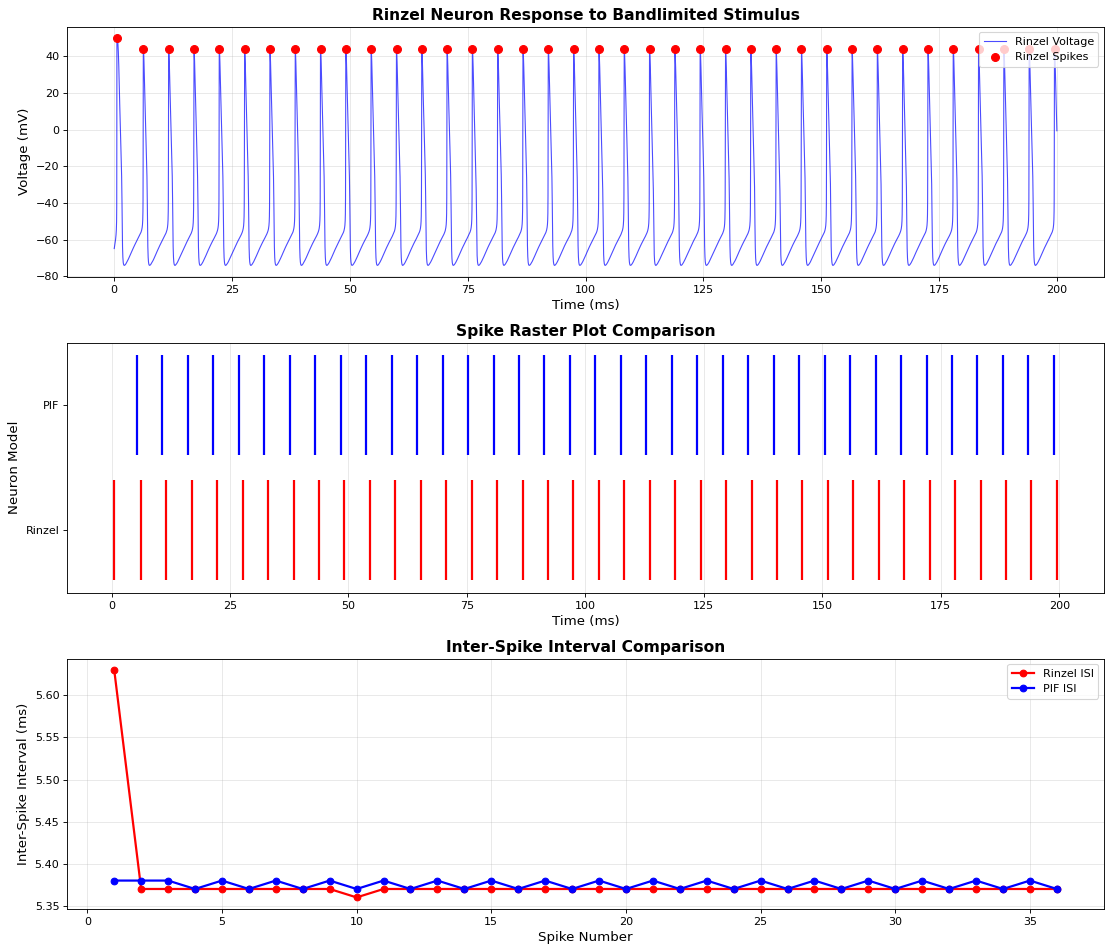


Spike Time Comparison
Number of Rinzel spikes: 38
Number of PIF spikes: 37
Comparing first 37 spikes

Spike time difference statistics:
  Mean: -4.6462 ms
  Std:  0.0599 ms
  Max:  4.7900 ms


In [13]:
# TODO: Plot Rinzel, PIF outputs and compare the Inter-spike intervals (time_diff)

fig, axes = plt.subplots(3, 1, figsize=(14, 12))

#Voltage w spike markers
ax1 = axes[0]
ax1.plot(t, V_rinzel, 'b-', linewidth=1, label='Rinzel Voltage', alpha=0.7)
ax1.scatter(tk_rinzel, V_rinzel[tk_idx_rinzel], c='red', s=50,
           marker='o', label='Rinzel Spikes', zorder=5)
ax1.set_xlabel('Time (ms)', fontsize=12)
ax1.set_ylabel('Voltage (mV)', fontsize=12)
ax1.set_title('Rinzel Neuron Response to Bandlimited Stimulus', fontsize=14, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Spike time comparison
ax2 = axes[1]
#raster
ax2.eventplot([tk_rinzel, tk_pif], lineoffsets=[1, 2], linelengths=0.8,
             colors=['red', 'blue'], linewidths=2)
ax2.set_yticks([1, 2])
ax2.set_yticklabels(['Rinzel', 'PIF'])
ax2.set_xlabel('Time (ms)', fontsize=12)
ax2.set_ylabel('Neuron Model', fontsize=12)
ax2.set_title('Spike Raster Plot Comparison', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='x')
ax2.set_ylim([0.5, 2.5])

#Inter-spike interval comparison
ax3 = axes[2]
#  ISIs
isi_rinzel = np.diff(tk_rinzel)
isi_pif = np.diff(tk_pif)

# Match the lengths and then we use minimum of the two
min_len = min(len(isi_rinzel), len(isi_pif))
isi_rinzel_matched = isi_rinzel[:min_len]
isi_pif_matched = isi_pif[:min_len]

spike_num = np.arange(1, min_len + 1)
ax3.plot(spike_num, isi_rinzel_matched, 'ro-', label='Rinzel ISI', linewidth=2, markersize=6)
ax3.plot(spike_num, isi_pif_matched, 'bo-', label='PIF ISI', linewidth=2, markersize=6)
ax3.set_xlabel('Spike Number', fontsize=12)
ax3.set_ylabel('Inter-Spike Interval (ms)', fontsize=12)
ax3.set_title('Inter-Spike Interval Comparison', fontsize=14, fontweight='bold')
ax3.legend()
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Calculate spike time differences!!!!
min_spikes = min(len(tk_rinzel), len(tk_pif))
spike_time_diff = tk_rinzel[:min_spikes] - tk_pif[:min_spikes]

print(f"\nSpike Time Comparison")
print(f"Number of Rinzel spikes: {len(tk_rinzel)}")
print(f"Number of PIF spikes: {len(tk_pif)}")
print(f"Comparing first {min_spikes} spikes")
print(f"\nSpike time difference statistics:")
print(f"  Mean: {np.mean(spike_time_diff):.4f} ms")
print(f"  Std:  {np.std(spike_time_diff):.4f} ms")
print(f"  Max:  {np.max(np.abs(spike_time_diff)):.4f} ms")

## Item (iii): Record PIF Error Statistics

In [14]:
# TODO: Initalize experiment
# Find a range of amplitude $C$ that is within the range of permissable input current to the Rinzel model.
# Too large and the limit cycle could collapse

C = np.linspace(0.5, 5.0, 10)  # Test 10 different amplitudes from 0.5 to 5 pA

avg_diff = np.zeros(len(C))
std_diff = np.zeros(len(C))

print(f"Testing {len(C)} different stimulus amplitudes:")
print(f"C range: {C[0]:.2f} to {C[-1]:.2f} pA")

Testing 10 different stimulus amplitudes:
C range: 0.50 to 5.00 pA


Running simulations across different amplitudes...


Testing amplitudes:   0%|          | 0/10 [00:00<?, ?it/s]


Simulations complete!


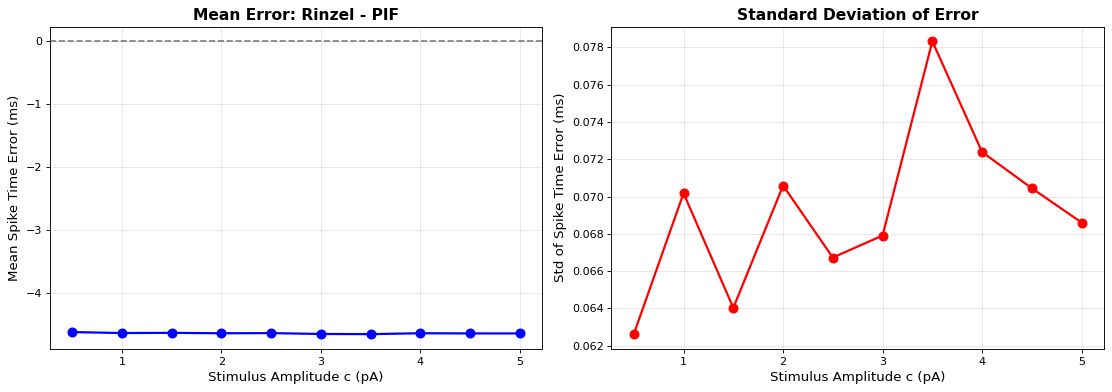


Error Statistics Summary
c = 0.50 pA: μ = -4.6261 ms, σ = 0.0626 ms
c = 1.00 pA: μ = -4.6416 ms, σ = 0.0702 ms
c = 1.50 pA: μ = -4.6383 ms, σ = 0.0640 ms
c = 2.00 pA: μ = -4.6452 ms, σ = 0.0706 ms
c = 2.50 pA: μ = -4.6428 ms, σ = 0.0667 ms
c = 3.00 pA: μ = -4.6566 ms, σ = 0.0679 ms
c = 3.50 pA: μ = -4.6590 ms, σ = 0.0783 ms
c = 4.00 pA: μ = -4.6448 ms, σ = 0.0724 ms
c = 4.50 pA: μ = -4.6477 ms, σ = 0.0704 ms
c = 5.00 pA: μ = -4.6478 ms, σ = 0.0686 ms


In [15]:
# TODO: Simulate the Rinzel and PIF for inputs I_ext = I + u(t) for different amplitude of u(t): max|u(t)| = c
# TODO: Compute the difference between interspike interval of the Rinzel and PIF,
# and calculate the mean/standard deviation of the error.

# Number of trials per amplitude to get better statistics
n_trials = 5

print("Running simulations across different amplitudes...")

for c_idx, c_amp in enumerate(tqdm(C, desc="Testing amplitudes")):

    #Store error
    all_errors = []

    for trial in range(n_trials):
        # Lets generate new random coefficients for each of the trials
        am_trial = np.zeros(2*M + 1, dtype=complex)
        for m in range(1, M+1):
            real_part = np.random.randn()
            imag_part = np.random.randn()
            am_trial[M + m] = real_part + 1j * imag_part
            am_trial[M - m] = np.conj(am_trial[M + m])

        # bandlimited signal then scaled to amplitude c
        u_trial = bandlmt_sig(t, am_trial, M, Omega)
        u_trial = c_amp * u_trial / np.max(np.abs(u_trial))

        #simulate
        I_ext_trial = bias + u_trial
        rinzel_trial = HodgkinHuxleyRinzel()
        res_trial = rinzel_trial.solve(t_sec, I_ext=I_ext_trial, solver='Euler',
                                       reset_initial_state=True, verbose=False)
        V_trial = res_trial['V'][0]

        spike_mask_trial = spike_detect(V_trial, height=0)
        tk_idx_trial = np.where(spike_mask_trial)[0]
        tk_rinzel_trial = t[tk_idx_trial]

        tk_pif_trial = pif(t, u_trial, PRC, T_period, dt)

        min_spikes_trial = min(len(tk_rinzel_trial), len(tk_pif_trial))

        if min_spikes_trial > 1:  # ugh we need at least 2 spikes to compute differences
            spike_diff = tk_rinzel_trial[:min_spikes_trial] - tk_pif_trial[:min_spikes_trial]
            all_errors.extend(spike_diff)

    if len(all_errors) > 0:
        avg_diff[c_idx] = np.mean(all_errors)
        std_diff[c_idx] = np.std(all_errors)
    else:
        avg_diff[c_idx] = np.nan
        std_diff[c_idx] = np.nan

print("\nSimulations complete!")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

#mean error v amplitude
ax1 = axes[0]
ax1.plot(C, avg_diff, 'bo-', linewidth=2, markersize=8)
ax1.axhline(y=0, color='k', linestyle='--', alpha=0.5)
ax1.set_xlabel('Stimulus Amplitude c (pA)', fontsize=12)
ax1.set_ylabel('Mean Spike Time Error (ms)', fontsize=12)
ax1.set_title('Mean Error: Rinzel - PIF', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)

#tandard deviation v amplitude
ax2 = axes[1]
ax2.plot(C, std_diff, 'ro-', linewidth=2, markersize=8)
ax2.set_xlabel('Stimulus Amplitude c (pA)', fontsize=12)
ax2.set_ylabel('Std of Spike Time Error (ms)', fontsize=12)
ax2.set_title('Standard Deviation of Error', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print summary statistics
print(f"\nError Statistics Summary")
for i, c_val in enumerate(C):
    print(f"c = {c_val:.2f} pA: μ = {avg_diff[i]:.4f} ms, σ = {std_diff[i]:.4f} ms")

# Problem 2: Synaptic Input and PRC

### Step 1. Simulate neuron with bias current

In [16]:
# TODO: Simulate the PostSynaptic Neuron with a bias current of 20pA
# use dt = 1e-5

dt_p2 = 1e-5
I_bias_p2 = 20.0

t_sim_p2 = np.arange(0, 100, dt_p2)
t_sim_p2_sec = t_sim_p2 * 1e-3

# postsynaptic HH neuron
hh_post = HodgkinHuxley()

# Simulate with constant bias
I_ext_p2 = np.ones_like(t_sim_p2_sec) * I_bias_p2
res_hh_post = hh_post.solve(t_sim_p2_sec, I_ext=I_ext_p2, solver='RK45',
                            reset_initial_state=True, verbose=False)

V_post = res_hh_post['V'][0]
n_post = res_hh_post['n'][0]
m_post = res_hh_post['m'][0]
h_post = res_hh_post['h'][0]

# Detect the spikes
spike_mask_post = spike_detect(V_post, height=0)
spike_idx_post = np.where(spike_mask_post)[0]
spike_times_post = t_sim_p2[spike_idx_post]

print(f"Simulated HH postsynaptic neuron with I = {I_bias_p2} pA")
print(f"Detected {len(spike_times_post)} spikes")
print(f"Voltage range: [{np.min(V_post):.2f}, {np.max(V_post):.2f}] mV")

# We are just going to extract one period of the limit cycle (just using the last two spikes)
if len(spike_idx_post) >= 2:
    period_p2 = spike_idx_post[-1] - spike_idx_post[-2]
    start_idx_p2 = spike_idx_post[-2]
    end_idx_p2 = spike_idx_post[-1]

    limitCycle_p2 = {
        'V': V_post[start_idx_p2:end_idx_p2],
        'n': n_post[start_idx_p2:end_idx_p2],
        'm': m_post[start_idx_p2:end_idx_p2],
        'h': h_post[start_idx_p2:end_idx_p2],
        't': t_sim_p2[start_idx_p2:end_idx_p2] - t_sim_p2[start_idx_p2]
    }

    print(f"Period: {period_p2 * dt_p2:.3f} ms ({period_p2} time steps)")
else:
    print("Warning: Not enough spikes to extract limit cycle!")


Simulated HH postsynaptic neuron with I = 20.0 pA
Detected 9 spikes
Voltage range: [-74.24, 49.31] mV
Period: 11.565 ms (1156469 time steps)



Spike Timing Information:
  Spike 1: 1.0077 ms
  Spike 2: 13.6295 ms
  Spike 3: 25.2455 ms
  Spike 4: 36.8158 ms
  Spike 5: 48.3811 ms
  Spike 6: 59.9458 ms
  Spike 7: 71.5105 ms
  Spike 8: 83.0752 ms
  Spike 9: 94.6399 ms

Inter-spike intervals: [12.62176 11.61601 11.57029 11.56532 11.56476 11.56471 11.5647  11.56469]
Mean ISI: 11.7040 ms
Period (from limit cycle): 11.5647 ms


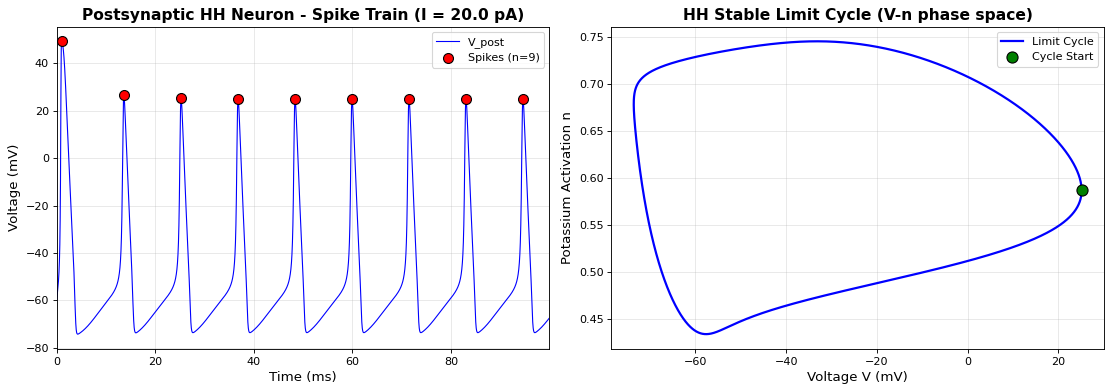

In [17]:
# TODO: plot the spike train V_post and the stable limit cycle

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

#voltage vs time
ax1 = axes[0]
ax1.plot(t_sim_p2, V_post, 'b-', linewidth=1, label='V_post')
ax1.scatter(spike_times_post, V_post[spike_idx_post], c='red', s=80,
           marker='o', label=f'Spikes (n={len(spike_times_post)})', zorder=5, edgecolors='black', linewidths=1)
ax1.set_xlabel('Time (ms)', fontsize=12)
ax1.set_ylabel('Voltage (mV)', fontsize=12)
ax1.set_title(f'Postsynaptic HH Neuron - Spike Train (I = {I_bias_p2} pA)', fontsize=14, fontweight='bold')
ax1.legend(loc='upper right')
ax1.grid(True, alpha=0.3)
ax1.set_xlim([0, t_sim_p2[-1]])

#  timing information
if len(spike_times_post) >= 2:
    print(f"\nSpike Timing Information:")
    for i, st in enumerate(spike_times_post):
        print(f"  Spike {i+1}: {st:.4f} ms")
    isi = np.diff(spike_times_post)
    print(f"\nInter-spike intervals: {isi}")
    print(f"Mean ISI: {np.mean(isi):.4f} ms")
    print(f"Period (from limit cycle): {period_p2 * dt_p2:.4f} ms")

# V vs n
ax2 = axes[1]
ax2.plot(limitCycle_p2['V'], limitCycle_p2['n'], 'b-', linewidth=2, label='Limit Cycle')
ax2.scatter(limitCycle_p2['V'][0], limitCycle_p2['n'][0], c='green', s=100,
           marker='o', label='Cycle Start', zorder=5, edgecolors='black', linewidths=1)
ax2.set_xlabel('Voltage V (mV)', fontsize=12)
ax2.set_ylabel('Potassium Activation n', fontsize=12)
ax2.set_title('HH Stable Limit Cycle (V-n phase space)', fontsize=14, fontweight='bold')
ax2.legend(loc='best')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Step 2. Generate the neuro transmitter traces

In [18]:
# TODO extract the time/index of maximum and minimum PRC

# Find times that end up corresponding to max and min PRC from the first Problem 1
idx_max_prc = np.argmax(PRC)
idx_min_prc = np.argmin(PRC)
t_max_prc_rinzel = limitCycle['t'][idx_max_prc]
t_min_prc_rinzel = limitCycle['t'][idx_min_prc]

#calculate phase
phase_max = idx_max_prc / len(PRC)
phase_min = idx_min_prc / len(PRC)

print(f"From Rinzel PRC (Problem 1):")
print(f"  PRC Maximum: {np.max(PRC):.4f} at t = {t_max_prc_rinzel:.3f} ms (phase {phase_max:.3f})")
print(f"  PRC Minimum: {np.min(PRC):.4f} at t = {t_min_prc_rinzel:.3f} ms (phase {phase_min:.3f})")
print(f"  Rinzel period: {period * dt:.3f} ms")

#IPORTANT: convert Rinzel phases to HH neuron timing
print(f"\nScaling Rinzel PRC phases to HH neuron (period = {period_p2 * dt_p2:.3f} ms):")
t_spike_max = phase_max * period_p2 * dt_p2  #scale phase to HH period
t_spike_min = phase_min * period_p2 * dt_p2  #scale phase to HH period

print(f"  Phase {phase_max:.3f} (max PRC) → HH time: {t_spike_max:.3f} ms")
print(f"  Phase {phase_min:.3f} (min PRC) → HH time: {t_spike_min:.3f} ms")
print(f"  Time separation: {abs(t_spike_max - t_spike_min):.3f} ms")

print(f"\nPresynaptic NT spike will be delivered at:")
print(f"  Condition 1 (max PRC): {t_spike_max:.3f} ms after spike (phase {phase_max:.3f})")
print(f"  Condition 2 (min PRC): {t_spike_min:.3f} ms after spike (phase {phase_min:.3f})")

From Rinzel PRC (Problem 1):
  PRC Maximum: 0.3920 at t = 1.580 ms (phase 0.294)
  PRC Minimum: -0.3120 at t = 3.460 ms (phase 0.644)
  Rinzel period: 5.370 ms

Scaling Rinzel PRC phases to HH neuron (period = 11.565 ms):
  Phase 0.294 (max PRC) → HH time: 3.403 ms
  Phase 0.644 (min PRC) → HH time: 7.451 ms
  Time separation: 4.049 ms

Presynaptic NT spike will be delivered at:
  Condition 1 (max PRC): 3.403 ms after spike (phase 0.294)
  Condition 2 (min PRC): 7.451 ms after spike (phase 0.644)


NT Spike Timing for HH Neuron:
  argmax(PRC) - Phase 0.294 → HH time: 3.403 ms
  argmin(PRC) - Phase 0.644 → HH time: 7.451 ms

Note: Times are scaled from Rinzel phases to match HH neuron period
  Rinzel period: 5.370 ms
  HH period: 11.565 ms
  Time separation: 4.049 ms


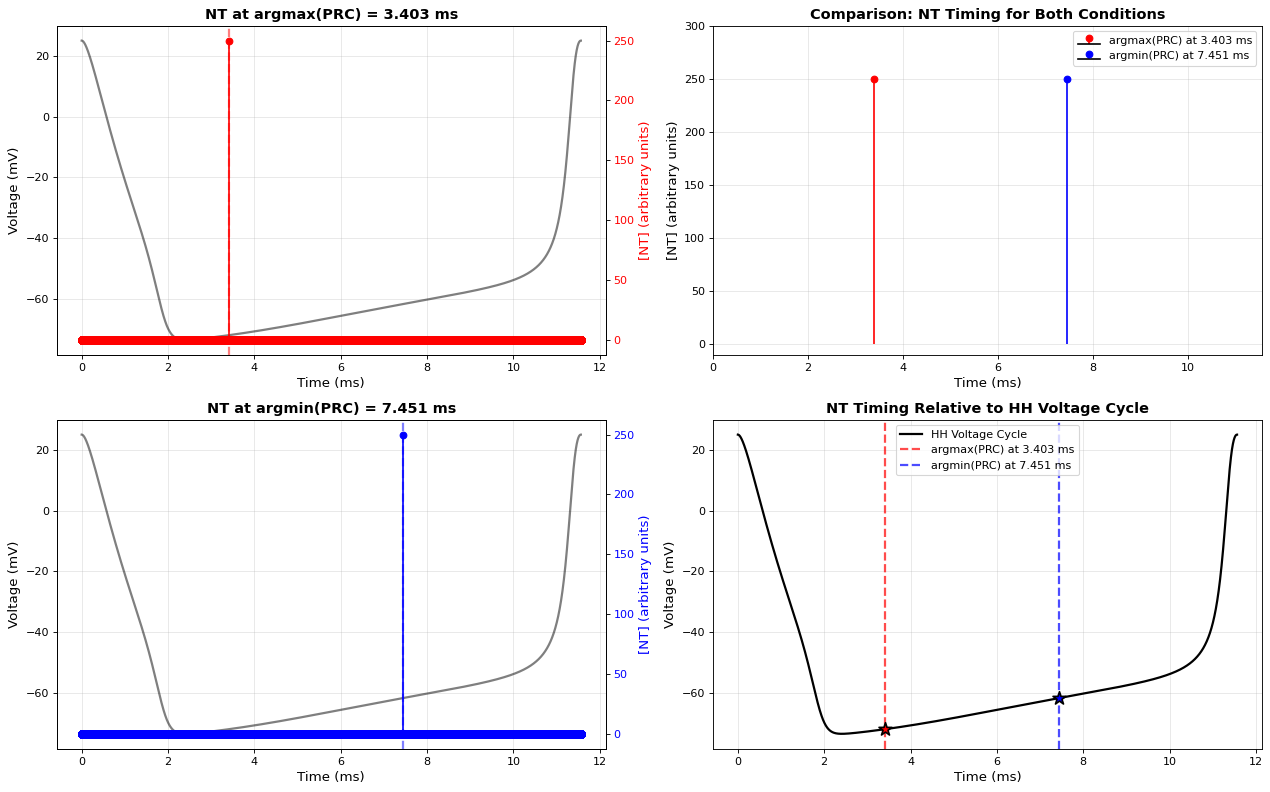


Note: NT spike times are from Rinzel PRC but applied to HH neuron cycle
Rinzel period: 5.370 ms
HH period: 11.565 ms


In [19]:
# TODO plot the NT for both conditions

NT_max = 250.0

print(f"NT Spike Timing for HH Neuron:")
print(f"  argmax(PRC) - Phase {idx_max_prc/len(PRC):.3f} → HH time: {t_spike_max:.3f} ms")
print(f"  argmin(PRC) - Phase {idx_min_prc/len(PRC):.3f} → HH time: {t_spike_min:.3f} ms")
print(f"\nNote: Times are scaled from Rinzel phases to match HH neuron period")
print(f"  Rinzel period: {period * dt:.3f} ms")
print(f"  HH period: {period_p2 * dt_p2:.3f} ms")
print(f"  Time separation: {abs(t_spike_max - t_spike_min):.3f} ms")

#simulate one period starting from a spike
# then where the NT input occurs
t_NT = limitCycle_p2['t']
NT_at_max = np.zeros_like(t_NT)
NT_at_min = np.zeros_like(t_NT)

#closest time index for spike delivery
idx_spike_max = np.argmin(np.abs(t_NT - t_spike_max))
idx_spike_min = np.argmin(np.abs(t_NT - t_spike_min))

# Delta spike approximated as impulse ----> set one time point to NT_max
NT_at_max[idx_spike_max] = NT_max
NT_at_min[idx_spike_min] = NT_max

#Show NT spikes in context with HH the voltage cycle!
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

ax1 = axes[0, 0]
ax1_twin = ax1.twinx()
# Plot voltage
ax1.plot(t_NT, limitCycle_p2['V'], 'k-', linewidth=2, alpha=0.5, label='HH Voltage')
#NT
ax1_twin.stem(t_NT, NT_at_max, linefmt='r-', markerfmt='ro', basefmt='r-',
              label=f'[NT] at {t_spike_max:.3f} ms')
ax1.axvline(x=t_spike_max, color='red', linestyle='--', alpha=0.5, linewidth=2)
ax1.set_xlabel('Time (ms)', fontsize=12)
ax1.set_ylabel('Voltage (mV)', fontsize=12, color='k')
ax1_twin.set_ylabel('[NT] (arbitrary units)', fontsize=12, color='r')
ax1.set_title(f'NT at argmax(PRC) = {t_spike_max:.3f} ms', fontsize=13, fontweight='bold')
ax1.tick_params(axis='y', labelcolor='k')
ax1_twin.tick_params(axis='y', labelcolor='r')
ax1.grid(True, alpha=0.3)

#NT at argmin(PRC) with voltage
ax2 = axes[1, 0]
ax2_twin = ax2.twinx()
ax2.plot(t_NT, limitCycle_p2['V'], 'k-', linewidth=2, alpha=0.5, label='HH Voltage')
ax2_twin.stem(t_NT, NT_at_min, linefmt='b-', markerfmt='bo', basefmt='b-',
              label=f'[NT] at {t_spike_min:.3f} ms')
ax2.axvline(x=t_spike_min, color='blue', linestyle='--', alpha=0.5, linewidth=2)
ax2.set_xlabel('Time (ms)', fontsize=12)
ax2.set_ylabel('Voltage (mV)', fontsize=12, color='k')
ax2_twin.set_ylabel('[NT] (arbitrary units)', fontsize=12, color='b')
ax2.set_title(f'NT at argmin(PRC) = {t_spike_min:.3f} ms', fontsize=13, fontweight='bold')
ax2.tick_params(axis='y', labelcolor='k')
ax2_twin.tick_params(axis='y', labelcolor='b')
ax2.grid(True, alpha=0.3)

ax3 = axes[0, 1]
ax3.stem([t_spike_max], [NT_max], linefmt='r-', markerfmt='ro', basefmt='k-',
         label=f'argmax(PRC) at {t_spike_max:.3f} ms')
ax3.stem([t_spike_min], [NT_max], linefmt='b-', markerfmt='bo', basefmt='k-',
         label=f'argmin(PRC) at {t_spike_min:.3f} ms')
ax3.set_xlabel('Time (ms)', fontsize=12)
ax3.set_ylabel('[NT] (arbitrary units)', fontsize=12)
ax3.set_title('Comparison: NT Timing for Both Conditions', fontsize=13, fontweight='bold')
ax3.set_xlim([0, t_NT[-1]])
ax3.set_ylim([-10, NT_max + 50])
ax3.legend()
ax3.grid(True, alpha=0.3)

#  NT spikes on voltage
ax4 = axes[1, 1]
ax4.plot(t_NT, limitCycle_p2['V'], 'k-', linewidth=2, label='HH Voltage Cycle')
ax4.axvline(x=t_spike_max, color='red', linestyle='--', linewidth=2, alpha=0.7,
           label=f'argmax(PRC) at {t_spike_max:.3f} ms')
ax4.axvline(x=t_spike_min, color='blue', linestyle='--', linewidth=2, alpha=0.7,
           label=f'argmin(PRC) at {t_spike_min:.3f} ms')
ax4.scatter([t_spike_max], [limitCycle_p2['V'][idx_spike_max]], c='red', s=150,
           marker='*', zorder=5, edgecolors='black', linewidths=1.5)
ax4.scatter([t_spike_min], [limitCycle_p2['V'][idx_spike_min]], c='blue', s=150,
           marker='*', zorder=5, edgecolors='black', linewidths=1.5)
ax4.set_xlabel('Time (ms)', fontsize=12)
ax4.set_ylabel('Voltage (mV)', fontsize=12)
ax4.set_title('NT Timing Relative to HH Voltage Cycle', fontsize=13, fontweight='bold')
ax4.legend(loc='best')
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nNote: NT spike times are from Rinzel PRC but applied to HH neuron cycle")
print(f"Rinzel period: {period * dt:.3f} ms")
print(f"HH period: {period_p2 * dt_p2:.3f} ms")

### Step 3.  Simulate and plot the synaptic current for AMPA synapse

In [20]:
# TODO: Use the Synaptic current as $u(t)$ to the postsynaptic Neuron
# TODO: link the synapse to Rinzel neuron, simulate over t using Euler's method

from compneuro.synapses.ampa import AMPA

#one period with synaptic input
# We'll simulate starting from the beginning of a cycle and then apply NT spike at the appropriate time

def simulate_with_synapse(synapse, NT_spike_time, t_sim, dt, I_bias, neuron_type='HH'):
    """
    Simulate postsynaptic neuron with the synaptic input.

    Args:
        synapse: Synapse model (like AMPA or GABA_A)
        NT_spike_time: essentially just time to deliver presynaptic spike (ms)
        t_sim: Time vector (ms)
        dt: Time resolution (ms)
        I_bias: Bias current (pA)
        neuron_type:HH

    Returns:
        Just a dictionary with results (V, s, g_syn, I_syn..)
    """

    # init Neuron
    if neuron_type == 'HH':
        neuron = HodgkinHuxley()

    # Init syunpase
    syn = synapse()

    # Storage arrays
    n_steps = len(t_sim)
    V = np.zeros(n_steps)
    n_state = np.zeros(n_steps)
    m_state = np.zeros(n_steps)
    h_state = np.zeros(n_steps)
    s = np.zeros(n_steps)
    g_syn = np.zeros(n_steps)
    I_syn_array = np.zeros(n_steps)

    # init conditoins
    V[0] = neuron.states['V'][0]
    n_state[0] = neuron.states['n'][0]
    m_state[0] = neuron.states['m'][0]
    h_state[0] = neuron.states['h'][0]
    s[0] = syn.states['s'][0]

    # index where NT spike is going to occur
    NT_idx = np.argmin(np.abs(t_sim - NT_spike_time))

    # Euler
    for i in range(n_steps - 1):
        # NT input
        if i == NT_idx:
            NT_input = NT_max / dt  # Should be scaling by dt to approximate the delta function
        else:
            NT_input = 0.0

        # Going to update the synapse state
        ds_dt = NT_input * syn.params['alpha'] * (1 - s[i]) - syn.params['beta'] * s[i]
        s[i+1] = s[i] + dt * ds_dt
        s[i+1] = np.clip(s[i+1], 0, 1)  # s between 0 and 1

        # compute synaptic conductance
        g_syn[i] = syn.params['g_max'] * s[i]

        #compute synaptic current: I_syn = g_syn * (V - E_rev)
        I_syn = -g_syn[i] * (V[i] - syn.params['E'])
        I_syn_array[i] = I_syn

        I_ext_total = I_bias + I_syn

        # update the neurons state
        states = [V[i], n_state[i], m_state[i], h_state[i]]
        d_states = neuron.ode(t_sim[i] * 1e-3, states, I_ext=I_ext_total)

        V[i+1] = V[i] + dt * d_states[0]
        n_state[i+1] = n_state[i] + dt * d_states[1]
        m_state[i+1] = m_state[i] + dt * d_states[2]
        h_state[i+1] = h_state[i] + dt * d_states[3]

    g_syn[-1] = syn.params['g_max'] * s[-1]
    I_syn_array[-1] = -g_syn[-1] * (V[-1] - syn.params['E'])

    return {
        'V': V,
        'n': n_state,
        'm': m_state,
        'h': h_state,
        's': s,
        'g_syn': g_syn,
        'I_syn': I_syn_array,
        't': t_sim
    }

print("Simulating AMPA synapse...")

# We shuld be Simulating for 2 PERIODS to see the effect on the NEXT spike!
t_extended = np.arange(0, 2 * limitCycle_p2['t'][-1], dt_p2)

#NT spike at argmax(PRC)
res_ampa_max = simulate_with_synapse(AMPA, t_spike_max, t_extended,
                                      dt_p2, I_bias_p2)

#NT spike at argmin(PRC)
res_ampa_min = simulate_with_synapse(AMPA, t_spike_min, t_extended,
                                      dt_p2, I_bias_p2)

print("AMPA simulations complete!")

Simulating AMPA synapse...
AMPA simulations complete!


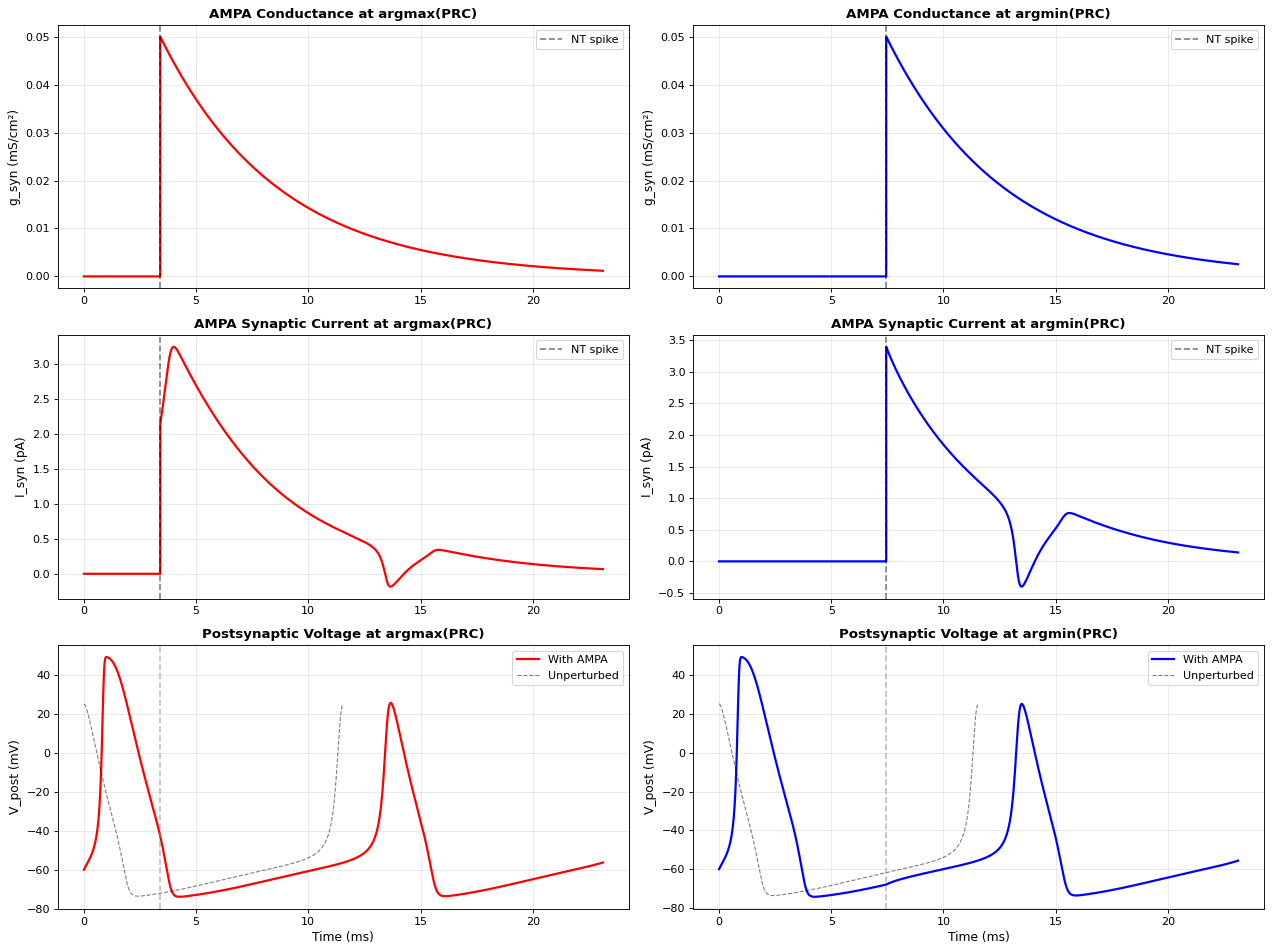

In [21]:
# TODO: Plot the synaptic conductance, synaptic current and postsynaptic voltage for each NT

# just creating these comphrehengsize plots for AMPA synapse
fig, axes = plt.subplots(3, 2, figsize=(16, 12))

# Left column is NT at argmax(PRC)
# Right column is NT at argmin(PRC)

#Synaptic Conductance
axes[0, 0].plot(res_ampa_max['t'], res_ampa_max['g_syn'], 'r-', linewidth=2)
axes[0, 0].axvline(x=t_spike_max, color='k', linestyle='--', alpha=0.5, label='NT spike')
axes[0, 0].set_ylabel('g_syn (mS/cm²)', fontsize=11)
axes[0, 0].set_title('AMPA Conductance at argmax(PRC)', fontsize=12, fontweight='bold')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].legend()

axes[0, 1].plot(res_ampa_min['t'], res_ampa_min['g_syn'], 'b-', linewidth=2)
axes[0, 1].axvline(x=t_spike_min, color='k', linestyle='--', alpha=0.5, label='NT spike')
axes[0, 1].set_ylabel('g_syn (mS/cm²)', fontsize=11)
axes[0, 1].set_title('AMPA Conductance at argmin(PRC)', fontsize=12, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].legend()

#row 2: Synaptic Current
axes[1, 0].plot(res_ampa_max['t'], res_ampa_max['I_syn'], 'r-', linewidth=2)
axes[1, 0].axvline(x=t_spike_max, color='k', linestyle='--', alpha=0.5, label='NT spike')
axes[1, 0].set_ylabel('I_syn (pA)', fontsize=11)
axes[1, 0].set_title('AMPA Synaptic Current at argmax(PRC)', fontsize=12, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].legend()

axes[1, 1].plot(res_ampa_min['t'], res_ampa_min['I_syn'], 'b-', linewidth=2)
axes[1, 1].axvline(x=t_spike_min, color='k', linestyle='--', alpha=0.5, label='NT spike')
axes[1, 1].set_ylabel('I_syn (pA)', fontsize=11)
axes[1, 1].set_title('AMPA Synaptic Current at argmin(PRC)', fontsize=12, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].legend()

#Row 3: Postsynaptic Voltage
axes[2, 0].plot(res_ampa_max['t'], res_ampa_max['V'], 'r-', linewidth=2, label='With AMPA')
axes[2, 0].plot(limitCycle_p2['t'], limitCycle_p2['V'], 'k--', linewidth=1, alpha=0.5, label='Unperturbed')
axes[2, 0].axvline(x=t_spike_max, color='gray', linestyle='--', alpha=0.5)
axes[2, 0].set_xlabel('Time (ms)', fontsize=11)
axes[2, 0].set_ylabel('V_post (mV)', fontsize=11)
axes[2, 0].set_title('Postsynaptic Voltage at argmax(PRC)', fontsize=12, fontweight='bold')
axes[2, 0].grid(True, alpha=0.3)
axes[2, 0].legend()

axes[2, 1].plot(res_ampa_min['t'], res_ampa_min['V'], 'b-', linewidth=2, label='With AMPA')
axes[2, 1].plot(limitCycle_p2['t'], limitCycle_p2['V'], 'k--', linewidth=1, alpha=0.5, label='Unperturbed')
axes[2, 1].axvline(x=t_spike_min, color='gray', linestyle='--', alpha=0.5)
axes[2, 1].set_xlabel('Time (ms)', fontsize=11)
axes[2, 1].set_ylabel('V_post (mV)', fontsize=11)
axes[2, 1].set_title('Postsynaptic Voltage at argmin(PRC)', fontsize=12, fontweight='bold')
axes[2, 1].grid(True, alpha=0.3)
axes[2, 1].legend()

plt.tight_layout()
plt.show()

### Step 4. Postsynaptic limit cycle with synaptic injection

/tmp/ipython-input-3515951030.py:45: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


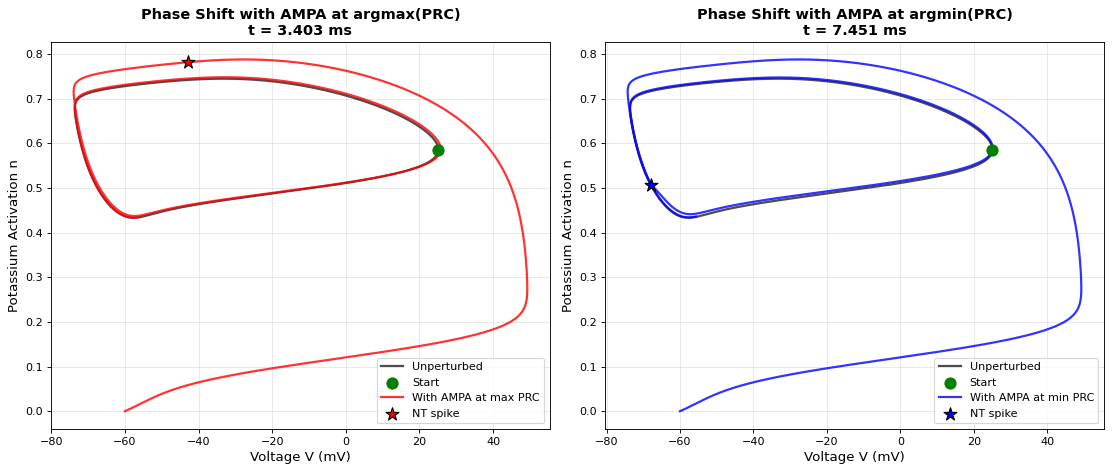


AMPA Phase Shift Analysis
At argmax(PRC): Next spike occurred at 13.672 ms
  Expected (unperturbed): 11.565 ms
  Phase shift: 2.107 ms (delayed)
  Number of spikes detected: 2

At argmin(PRC): Next spike occurred at 13.491 ms
  Expected (unperturbed): 11.565 ms
  Phase shift: 1.927 ms (delayed)
  Number of spikes detected: 2


In [22]:
# TODO: Plot
# overlay the resulting spike_train and limit cycle on the plots from **1.**

# Plot the phase space overlays to now show the different phase shifts
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: AMPA at the argmax(PRC)
ax1 = axes[0]
# Unperturbed
ax1.plot(limitCycle_p2['V'], limitCycle_p2['n'], 'k-', linewidth=2, label='Unperturbed', alpha=0.7)
ax1.scatter(limitCycle_p2['V'][0], limitCycle_p2['n'][0], c='green', s=100,
           marker='o', label='Start', zorder=5)
# Perturbed
ax1.plot(res_ampa_max['V'], res_ampa_max['n'], 'r-', linewidth=2, label='With AMPA at max PRC', alpha=0.8)
# NT spike marked
NT_idx_max = np.argmin(np.abs(res_ampa_max['t'] - t_spike_max))
ax1.scatter(res_ampa_max['V'][NT_idx_max], res_ampa_max['n'][NT_idx_max],
           c='red', s=150, marker='*', label='NT spike', zorder=6, edgecolors='black', linewidths=1)
ax1.set_xlabel('Voltage V (mV)', fontsize=12)
ax1.set_ylabel('Potassium Activation n', fontsize=12)
ax1.set_title(f'Phase Shift with AMPA at argmax(PRC)\nt = {t_spike_max:.3f} ms',
             fontsize=13, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# AMPA at argmin(PRC)
ax2 = axes[1]
# Unperturbed
ax2.plot(limitCycle_p2['V'], limitCycle_p2['n'], 'k-', linewidth=2, label='Unperturbed', alpha=0.7)
ax2.scatter(limitCycle_p2['V'][0], limitCycle_p2['n'][0], c='green', s=100,
           marker='o', label='Start', zorder=5)
# Perturbed
ax2.plot(res_ampa_min['V'], res_ampa_min['n'], 'b-', linewidth=2, label='With AMPA at min PRC', alpha=0.8)
#NT spike was delivered
NT_idx_min = np.argmin(np.abs(res_ampa_min['t'] - t_spike_min))
ax2.scatter(res_ampa_min['V'][NT_idx_min], res_ampa_min['n'][NT_idx_min],
           c='blue', s=150, marker='*', label='NT spike', zorder=6, edgecolors='black', linewidths=1)
ax2.set_xlabel('Voltage V (mV)', fontsize=12)
ax2.set_ylabel('Potassium Activation n', fontsize=12)
ax2.set_title(f'Phase Shift with AMPA at argmin(PRC)\nt = {t_spike_min:.3f} ms',
             fontsize=13, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Analyze phase shifts
print("\nAMPA Phase Shift Analysis")
spike_mask_ampa_max = spike_detect(res_ampa_max['V'], height=0)
spike_idx_ampa_max = np.where(spike_mask_ampa_max)[0]

spike_mask_ampa_min = spike_detect(res_ampa_min['V'], height=0)
spike_idx_ampa_min = np.where(spike_mask_ampa_min)[0]

# Lets find the the LAST spike (just the one completing the perturbed cycle)
if len(spike_idx_ampa_max) > 0:
    t_spike_ampa_max = res_ampa_max['t'][spike_idx_ampa_max[-1]]
    expected_spike_time = limitCycle_p2['t'][-1]  # End of unperturbed cycle
    shift_max = t_spike_ampa_max - expected_spike_time
    print(f"At argmax(PRC): Next spike occurred at {t_spike_ampa_max:.3f} ms")
    print(f"  Expected (unperturbed): {expected_spike_time:.3f} ms")
    print(f"  Phase shift: {shift_max:.3f} ms ({'advanced' if shift_max < 0 else 'delayed'})")
    print(f"  Number of spikes detected: {len(spike_idx_ampa_max)}")

if len(spike_idx_ampa_min) > 0:
    t_spike_ampa_min = res_ampa_min['t'][spike_idx_ampa_min[-1]]
    expected_spike_time = limitCycle_p2['t'][-1]
    shift_min = t_spike_ampa_min - expected_spike_time
    print(f"\nAt argmin(PRC): Next spike occurred at {t_spike_ampa_min:.3f} ms")
    print(f"  Expected (unperturbed): {expected_spike_time:.3f} ms")
    print(f"  Phase shift: {shift_min:.3f} ms ({'advanced' if shift_min < 0 else 'delayed'})")
    print(f"  Number of spikes detected: {len(spike_idx_ampa_min)}")

### Step 5: Simulate and plot the synapctic current for GABA_A synapse

Simulating GABA_A synapse...
GABA_A simulations complete!


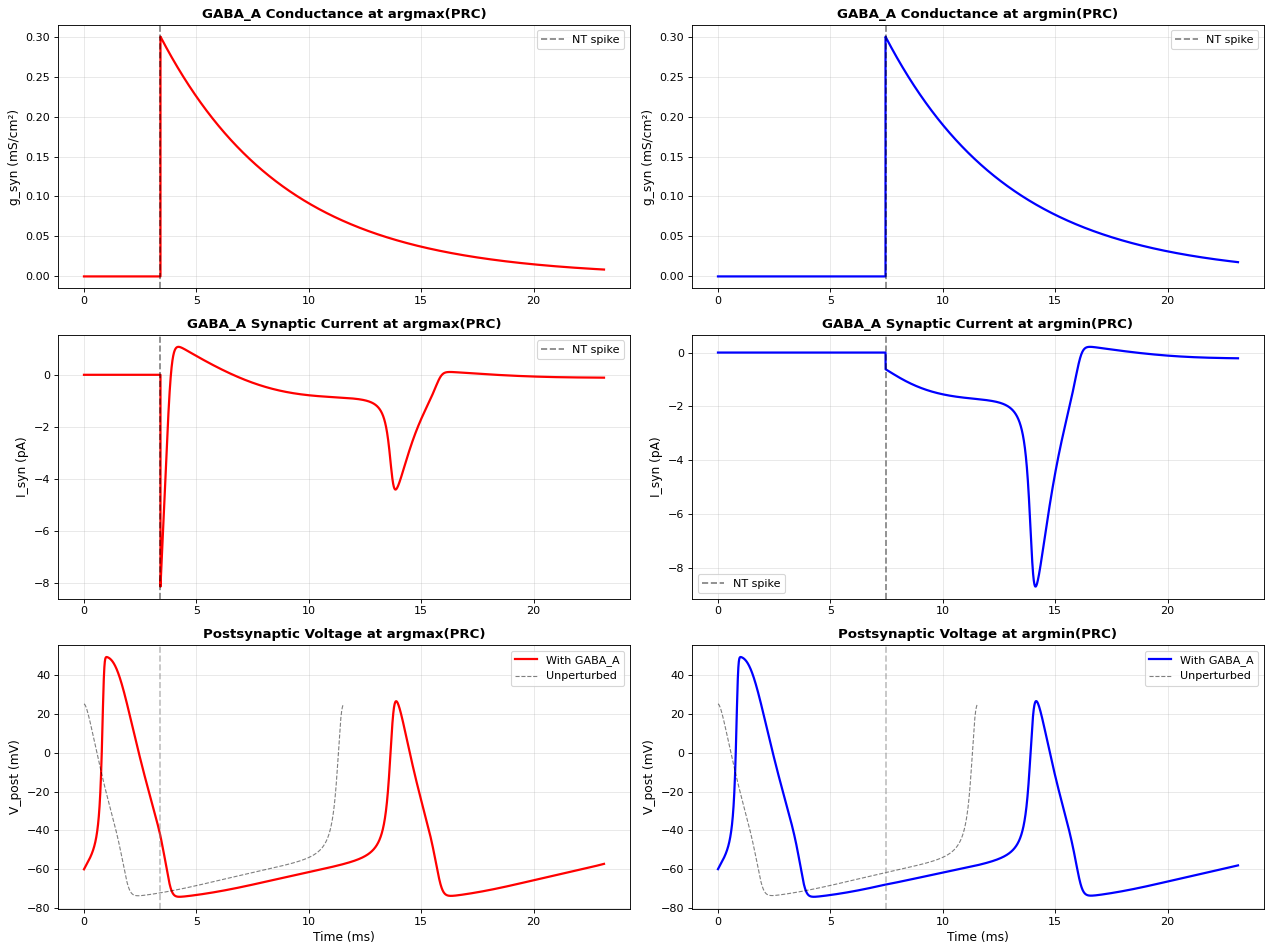

/tmp/ipython-input-252313600.py:104: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()


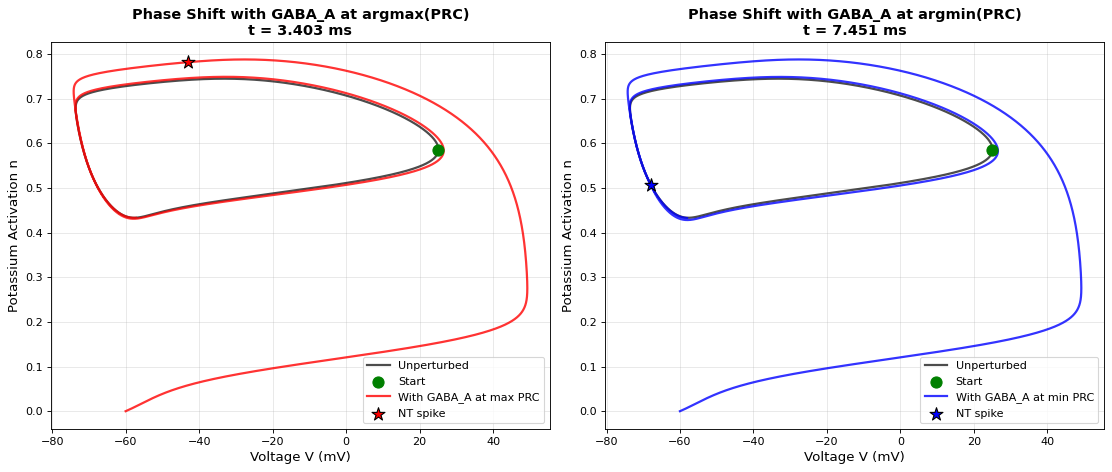


=== GABA_A Phase Shift Analysis ===
At argmax(PRC): Next spike occurred at 13.885 ms
  Expected (unperturbed): 11.565 ms
  Phase shift: 2.320 ms (delayed)
  Number of spikes detected: 2

At argmin(PRC): Next spike occurred at 14.153 ms
  Expected (unperturbed): 11.565 ms
  Phase shift: 2.589 ms (delayed)
  Number of spikes detected: 2


In [23]:
from compneuro.synapses.gaba_a import GABA_A

#basically just the same thing for AMPA but this time for GABA
print("Simulating GABA_A synapse...")

#NT spike at argmax(PRC)
res_gaba_max = simulate_with_synapse(GABA_A, t_spike_max, t_extended,
                                      dt_p2, I_bias_p2)

#NT spike at argmin(PRC)
res_gaba_min = simulate_with_synapse(GABA_A, t_spike_min, t_extended,
                                      dt_p2, I_bias_p2)

print("GABA_A simulations complete!")

fig, axes = plt.subplots(3, 2, figsize=(16, 12))

axes[0, 0].plot(res_gaba_max['t'], res_gaba_max['g_syn'], 'r-', linewidth=2)
axes[0, 0].axvline(x=t_spike_max, color='k', linestyle='--', alpha=0.5, label='NT spike')
axes[0, 0].set_ylabel('g_syn (mS/cm²)', fontsize=11)
axes[0, 0].set_title('GABA_A Conductance at argmax(PRC)', fontsize=12, fontweight='bold')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].legend()

axes[0, 1].plot(res_gaba_min['t'], res_gaba_min['g_syn'], 'b-', linewidth=2)
axes[0, 1].axvline(x=t_spike_min, color='k', linestyle='--', alpha=0.5, label='NT spike')
axes[0, 1].set_ylabel('g_syn (mS/cm²)', fontsize=11)
axes[0, 1].set_title('GABA_A Conductance at argmin(PRC)', fontsize=12, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].legend()

# Row 2: Synaptic Current
axes[1, 0].plot(res_gaba_max['t'], res_gaba_max['I_syn'], 'r-', linewidth=2)
axes[1, 0].axvline(x=t_spike_max, color='k', linestyle='--', alpha=0.5, label='NT spike')
axes[1, 0].set_ylabel('I_syn (pA)', fontsize=11)
axes[1, 0].set_title('GABA_A Synaptic Current at argmax(PRC)', fontsize=12, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].legend()

axes[1, 1].plot(res_gaba_min['t'], res_gaba_min['I_syn'], 'b-', linewidth=2)
axes[1, 1].axvline(x=t_spike_min, color='k', linestyle='--', alpha=0.5, label='NT spike')
axes[1, 1].set_ylabel('I_syn (pA)', fontsize=11)
axes[1, 1].set_title('GABA_A Synaptic Current at argmin(PRC)', fontsize=12, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].legend()

# Row 3: Postsynaptic Voltage
axes[2, 0].plot(res_gaba_max['t'], res_gaba_max['V'], 'r-', linewidth=2, label='With GABA_A')
axes[2, 0].plot(limitCycle_p2['t'], limitCycle_p2['V'], 'k--', linewidth=1, alpha=0.5, label='Unperturbed')
axes[2, 0].axvline(x=t_spike_max, color='gray', linestyle='--', alpha=0.5)
axes[2, 0].set_xlabel('Time (ms)', fontsize=11)
axes[2, 0].set_ylabel('V_post (mV)', fontsize=11)
axes[2, 0].set_title('Postsynaptic Voltage at argmax(PRC)', fontsize=12, fontweight='bold')
axes[2, 0].grid(True, alpha=0.3)
axes[2, 0].legend()

axes[2, 1].plot(res_gaba_min['t'], res_gaba_min['V'], 'b-', linewidth=2, label='With GABA_A')
axes[2, 1].plot(limitCycle_p2['t'], limitCycle_p2['V'], 'k--', linewidth=1, alpha=0.5, label='Unperturbed')
axes[2, 1].axvline(x=t_spike_min, color='gray', linestyle='--', alpha=0.5)
axes[2, 1].set_xlabel('Time (ms)', fontsize=11)
axes[2, 1].set_ylabel('V_post (mV)', fontsize=11)
axes[2, 1].set_title('Postsynaptic Voltage at argmin(PRC)', fontsize=12, fontweight='bold')
axes[2, 1].grid(True, alpha=0.3)
axes[2, 1].legend()

plt.tight_layout()
plt.show()

# GABA_A phase space overlays
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# GABA_A at argmax(PRC)
ax1 = axes[0]
ax1.plot(limitCycle_p2['V'], limitCycle_p2['n'], 'k-', linewidth=2, label='Unperturbed', alpha=0.7)
ax1.scatter(limitCycle_p2['V'][0], limitCycle_p2['n'][0], c='green', s=100,
           marker='o', label='Start', zorder=5)
ax1.plot(res_gaba_max['V'], res_gaba_max['n'], 'r-', linewidth=2, label='With GABA_A at max PRC', alpha=0.8)
NT_idx_max_gaba = np.argmin(np.abs(res_gaba_max['t'] - t_spike_max))
ax1.scatter(res_gaba_max['V'][NT_idx_max_gaba], res_gaba_max['n'][NT_idx_max_gaba],
           c='red', s=150, marker='*', label='NT spike', zorder=6, edgecolors='black', linewidths=1)
ax1.set_xlabel('Voltage V (mV)', fontsize=12)
ax1.set_ylabel('Potassium Activation n', fontsize=12)
ax1.set_title(f'Phase Shift with GABA_A at argmax(PRC)\nt = {t_spike_max:.3f} ms',
             fontsize=13, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

#GABA_A at argmin(PRC)
ax2 = axes[1]
ax2.plot(limitCycle_p2['V'], limitCycle_p2['n'], 'k-', linewidth=2, label='Unperturbed', alpha=0.7)
ax2.scatter(limitCycle_p2['V'][0], limitCycle_p2['n'][0], c='green', s=100,
           marker='o', label='Start', zorder=5)
ax2.plot(res_gaba_min['V'], res_gaba_min['n'], 'b-', linewidth=2, label='With GABA_A at min PRC', alpha=0.8)
NT_idx_min_gaba = np.argmin(np.abs(res_gaba_min['t'] - t_spike_min))
ax2.scatter(res_gaba_min['V'][NT_idx_min_gaba], res_gaba_min['n'][NT_idx_min_gaba],
           c='blue', s=150, marker='*', label='NT spike', zorder=6, edgecolors='black', linewidths=1)
ax2.set_xlabel('Voltage V (mV)', fontsize=12)
ax2.set_ylabel('Potassium Activation n', fontsize=12)
ax2.set_title(f'Phase Shift with GABA_A at argmin(PRC)\nt = {t_spike_min:.3f} ms',
             fontsize=13, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# GABA_A over diff phase shifts
print("\n=== GABA_A Phase Shift Analysis ===")
spike_mask_gaba_max = spike_detect(res_gaba_max['V'], height=0)
spike_idx_gaba_max = np.where(spike_mask_gaba_max)[0]

spike_mask_gaba_min = spike_detect(res_gaba_min['V'], height=0)
spike_idx_gaba_min = np.where(spike_mask_gaba_min)[0]

#Use the LAST spike to measure phase shift
if len(spike_idx_gaba_max) > 0:
    t_spike_gaba_max = res_gaba_max['t'][spike_idx_gaba_max[-1]]
    expected_spike_time = limitCycle_p2['t'][-1]
    shift_max_gaba = t_spike_gaba_max - expected_spike_time
    print(f"At argmax(PRC): Next spike occurred at {t_spike_gaba_max:.3f} ms")
    print(f"  Expected (unperturbed): {expected_spike_time:.3f} ms")
    print(f"  Phase shift: {shift_max_gaba:.3f} ms ({'advanced' if shift_max_gaba < 0 else 'delayed'})")
    print(f"  Number of spikes detected: {len(spike_idx_gaba_max)}")

if len(spike_idx_gaba_min) > 0:
    t_spike_gaba_min = res_gaba_min['t'][spike_idx_gaba_min[-1]]
    expected_spike_time = limitCycle_p2['t'][-1]
    shift_min_gaba = t_spike_gaba_min - expected_spike_time
    print(f"\nAt argmin(PRC): Next spike occurred at {t_spike_gaba_min:.3f} ms")
    print(f"  Expected (unperturbed): {expected_spike_time:.3f} ms")
    print(f"  Phase shift: {shift_min_gaba:.3f} ms ({'advanced' if shift_min_gaba < 0 else 'delayed'})")
    print(f"  Number of spikes detected: {len(spike_idx_gaba_min)}")


### Step 6: Comment on your observations

# Observations: Synapse Type and Timing Effects


I think what immediately stood out to me is that both synapse types (AMPA and GABAA_A) ​managed to produce these phase-dependent shifts in spike timing, which from what I can tell is consistent with the principles discussed in the lecture on Phase Response Curves (or PRCs for short). In this experiment that we ran, we could observe that synaptic inputs were delivered at the PRC’s most advancing and most delaying phases, then scaled by the normalized phase rather than just absolute time in order to better match the HH neuron’s intrinsic oscillatory period. As was mentioned previously in class, this scaling is rather critical as the neuron’s responsiveness really depends on where the perturbation lands along its limit cycle, not on the absolute time alignment.

For the AMPA synapse (excitatory, where we had Erev​ ≈ 0 mV), we found that the next spike was still delayed in both tested phases (by approximately 2.107 ms at the PRC’s argmax and by a listed 1.927 ms at the argmin (which would be relative to the unperturbed 11.565 ms period)). I again believe that this illustrates one of the key lecture takeaways, that even an excitatory conductance can somewhat yield a net phase delay if it manages to perturb the membrane potential into a slower region of its limit cycle. We would conclude then that the effect of excitation is therefore not really universally advancing. I would say that it might actually depend more on the instantaneous membrane voltage V relative to the synaptic reversal potential Erev​ and (also) on the geometry of the orbit that it gets in state space.

We see that In contrast, this GABAA_A​ synapse (inhibitory this time, with Erev​≈−70 mV) actually produced larger delays at both of its phases (with around 2.320 ms at the argmax and a 2.589 ms at the argmin) which would be consistent with the explanation in the lecture that the inhibitory or shunting inputs typically end up moving the system away from the threshold trajectory or slow its progress along the cycle. We find that this happens to align with the conductance model Isyn​=gsyn​(t)(V−ES​), where the direction and magnitude of the perturbation is really just dependant on both the Es​ and also the momentary voltage.

We most definitely saw that timing, or phase proved rather decisive at the millisecond level. To explain, we observed that the two chosen phases (roughly ~29% and ~64% through the cycle) actually correspond to a couple distinct positions on the oscillatory trajectory, roughly 3.4 ms and 7.4 ms into the HH cycle. Moreover, as was predicted by the PRC lectures, the same input is able to cause different phase shifts depending on when it actually arrives. We find that early in the cycle, a perturbation tends to have little effect due to refractory recovery, while later inputs can either advance or delay depending on how they end up interacting with the nonlinear dynamics beholden to the membrane.

Overall, I think we would say that these findings reinforce what we hear in class during the lectures. We find that synapse type determines the baseline influence (AMPA generally advancing and GABA_A​ generally delaying) and also that the precise phase of presynaptic input determines the magnitude and direction of that effect. I would say that the fact that both the AMPA and the GABAA_AA​ ended up producing small but consistent delays should be reflective of specific conductance magnitudes, waveform gsyn​(t), and phase selections occurring in this setup.
